# Where MERF and GPBoost get their noise variance from

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/panel_merf_gpboost_variance.ipynb)

MERF and GPBoost both fit a nonlinear fixed part with trees and a random intercept per unit, and
both return a variance decomposition. GPBoost also returns a predictive interval built from it.

Both estimate the noise variance from residuals on the rows the fixed part was trained on. This
notebook measures what that costs. The data comes from a known function with a known group variance
and a known noise variance, both 1.0, so every estimate can be put next to the value it is trying
to recover.

Every method gets the same tuning grid, tree structure and rounds together, picked on a validation
split. Five seeds.

About half an hour on a laptop CPU, and longer on a free Colab runtime.

In [ ]:
!pip install -q gpboost==1.7.4 merf==1.0 lightgbm==4.7.0 scikit-learn

In [2]:
import time, logging, warnings
import numpy as np, pandas as pd
import lightgbm as lgb, gpboost as gpb
from merf import MERF
from sklearn.ensemble import RandomForestRegressor
import importlib.metadata as md

warnings.filterwarnings("ignore")
logging.getLogger("merf").setLevel(logging.ERROR)
pd.set_option("display.width", 200, "display.max_columns", 40)
print("gpboost", gpb.__version__, "| lightgbm", lgb.__version__, "| merf", md.version("merf"))

gpboost 1.7.4 | lightgbm 4.7.0 | merf 1.0


## The panel

120 units with 8 training rows each, plus 2 validation and 4 test rows per unit, and 40 units that
never appear in training. The fixed part is Friedman #1 rescaled to a standard deviation near 2.
The unit effect is a random intercept with variance 1.0 and the noise variance is 1.0, so a
calibrated 90% interval on a seen unit needs a half width near 1.73, which is 1.645 times the
square root of the noise variance plus the posterior variance of an intercept estimated from 8
rows.

Rows within a unit are independent draws. Real panels usually have serial correlation on top of
this, which this design leaves out.

In [3]:
SB2, SE2, Z90 = 1.0, 1.0, 1.6448536269514722
NG, T_TR, T_VA, T_TE, NG_NEW = 120, 8, 2, 4, 40
ROUNDS = [50, 100, 200, 400, 800]
STRUCTS = [(8, 20), (31, 20), (31, 50), (63, 10)]        # num_leaves, min_data_in_leaf
BASE = {"objective": "regression_l2", "learning_rate": 0.05, "num_leaves": 31,
        "min_data_in_leaf": 20, "verbose": -1}


def F(X):
    f = 10*np.sin(np.pi*X[:, 0]*X[:, 1]) + 20*(X[:, 2]-0.5)**2 + 10*X[:, 3] + 5*X[:, 4]
    return (f - 14.4) / 2.5


def draw(rng, n_groups, n_per, offset, b):
    g = np.repeat(np.arange(n_groups) + offset, n_per)
    X = rng.uniform(size=(len(g), 5))
    return X, g, F(X) + b[g - offset] + rng.normal(0, np.sqrt(SE2), len(g))


def make(seed, n_per=T_TR):
    rng = np.random.default_rng(seed)
    b = rng.normal(0, np.sqrt(SB2), NG)
    d = {k: draw(rng, NG, n, 0, b) for k, n in [("train", n_per), ("val", T_VA), ("test", T_TE)]}
    d["new"] = draw(rng, NG_NEW, n_per, 10_000, rng.normal(0, np.sqrt(SB2), NG_NEW))
    return d


def rmse(y, p):
    return float(np.sqrt(np.mean((y - p)**2)))


def coverage(y, mean, var):
    s = np.sqrt(np.maximum(var, 0.0))
    return float(np.mean((y >= mean - Z90*s) & (y <= mean + Z90*s)))


def pick(df):
    return df.loc[df["rmse_val"].idxmin()]


d0 = make(0)
print({k: len(v[2]) for k, v in d0.items()}, "| sd(y) =", round(d0["train"][2].std(), 3))

{'train': 960, 'val': 240, 'test': 480, 'new': 320} | sd(y) = 2.306


## GPBoost and GPBoostOOS

GPBoost re-estimates the covariance parameters in every boosting iteration
(`train_gp_model_cov_pars`, default true), from the residuals of the current fit. GPBoostOOS is
Algorithm 2 of Sigrist (2022): fit the predictor function on each of four folds, estimate the
covariance parameters from the residuals on the rows left out of each, then refit on everything
with those parameters held fixed. Sigrist introduces it in section 3.3 for exactly the bias measured below.

`score` also takes a `cov_pars` override, which is how the last table in this notebook separates
the biased variance from the rest of the gap.

In [4]:
def gp_fit(X, g, y, params, m, init_cov=None):
    gp = gpb.GPModel(group_data=g, likelihood="gaussian")
    if init_cov is not None:
        gp.set_optim_params(params={"init_cov_pars": np.asarray(init_cov, float)})
    bst = gpb.train(params=params, train_set=gpb.Dataset(X, y), gp_model=gp,
                    num_boost_round=m, train_gp_model_cov_pars=init_cov is None)
    return bst, np.asarray(gp.get_cov_pars(), float).ravel()[:2]


K_FOLDS = 4


def gp_oos(X, g, y, params, m, seed):
    u = np.unique(g)
    fold = np.random.default_rng(seed).integers(0, K_FOLDS, len(u))[np.searchsorted(u, g)]
    f_oos = np.empty(len(y))
    for k in range(K_FOLDS):
        tr, va = fold != k, fold == k
        bst, _ = gp_fit(X[tr], g[tr], y[tr], params, m)
        f_oos[va] = bst.predict(data=X[va], group_data_pred=g[va],
                                pred_latent=True)["fixed_effect"]
    gp = gpb.GPModel(group_data=g, likelihood="gaussian")
    gp.fit(y=y - f_oos)
    cov = np.asarray(gp.get_cov_pars(), float).ravel()[:2]
    return gp_fit(X, g, y, params, m, init_cov=cov)[0], cov


def score(bst, d, cov_pars=None):
    X, g, _ = d["test"]
    out = {"rmse_F": rmse(F(X), bst.predict(data=X, group_data_pred=g,
                                            pred_latent=True)["fixed_effect"])}
    for part in ("val", "test", "new"):
        X, g, y = d[part]
        p = bst.predict(data=X, group_data_pred=g, predict_var=True, cov_pars=cov_pars)
        out[f"rmse_{part}"] = rmse(y, p["response_mean"])
        out[f"cov_{part}"] = coverage(y, p["response_mean"], p["response_var"])
    return out


def gp_grid(d, seed, oos=False, structs=STRUCTS, rounds=ROUNDS):
    rows = []
    for nl, md_ in structs:
        p = dict(BASE, num_leaves=nl, min_data_in_leaf=md_)
        for m in rounds:
            t = time.time()
            bst, cov = (gp_oos(*d["train"], p, m, seed) if oos else gp_fit(*d["train"], p, m))
            rows.append({"leaves": nl, "min_data": md_, "M": m, "s2": cov[0], "s2b": cov[1],
                         "time": time.time() - t, **score(bst, d)})
    return pd.DataFrame(rows)

## LightGBM with the unit id as a categorical feature

The usual shortcut, and the honest baseline. `cat_smooth` shrinks each level towards the global
mean, and its default of 10 is large next to 8 rows per unit, so it is part of the grid. The
`id_gain_share` column is there to check that the id is used at all.

One fit per configuration at the largest round count, with shorter counts read off the same model.

In [5]:
def lgb_grid(d, use_id, structs=STRUCTS, rounds=ROUNDS, smooths=(None, 0, 1, 2, 5)):
    Xtr, gtr, ytr = d["train"]
    A = (lambda X, g: np.c_[X, g]) if use_id else (lambda X, g: X)
    rows = []
    for nl, md_ in structs:
        for cs in (smooths if use_id else (None,)):
            p = dict(BASE, num_leaves=nl, min_data_in_leaf=md_)
            if cs is not None:
                p["cat_smooth"] = cs
            ds = lgb.Dataset(A(Xtr, gtr), ytr, categorical_feature=[5] if use_id else [])
            t = time.time()
            bst = lgb.train(p, ds, num_boost_round=max(rounds))
            el = time.time() - t
            for m in rounds:
                gain = bst.feature_importance("gain", iteration=m)
                r = {"leaves": nl, "min_data": md_, "cat_smooth": cs, "M": m,
                     "time": el * m / max(rounds),
                     "id_gain_share": float(gain[5] / gain.sum()) if use_id else 0.0}
                for part in ("val", "test", "new"):
                    X, g, y = d[part]
                    r[f"rmse_{part}"] = rmse(y, bst.predict(A(X, g), num_iteration=m))
                rows.append(r)
    return pd.DataFrame(rows)


chk = lgb_grid(d0, True).groupby("cat_smooth", dropna=False)[
    ["id_gain_share", "rmse_val", "rmse_test"]].mean()
print(chk.round(4).to_string(), "\n\nNaN is the default, cat_smooth = 10")

            id_gain_share  rmse_val  rmse_test
cat_smooth                                    
0.0                0.1825    1.2967     1.2490
1.0                0.2734    1.3079     1.2697
2.0                0.2861    1.3218     1.2962
5.0                0.2027    1.2816     1.2334
NaN                0.0000    1.5485     1.5694 

NaN is the default, cat_smooth = 10


## MERF

`merf` takes an explicit random effects design matrix `Z`, so a column of ones is a random
intercept and adding a covariate to `Z` gives a random slope. The base learner is free; here it is
LightGBM, refitted from scratch on every iteration, so its number of trees is the capacity knob.
With a bagged base learner such as a random forest, adding trees does not fit the training rows
harder, and the section further down shows what that changes.

The grid is 50, 100 and 400 trees rather than the full sweep used for GPBoost, and the tree
structure is left at the shared default, because a single MERF fit at 400 trees takes 20 to 45
seconds against under 3 seconds for GPBoost. So MERF is tuned less than the other methods here.

The package has no predictive interval, so the interval below is built from what it does expose:
`sigma2_hat` plus the posterior variance of that unit's intercept for a seen unit, which is what
GPBoost's own interval also includes, and `sigma2_hat` plus `D_hat` for an unseen unit, whose
intercept MERF predicts as zero.

In [6]:
def merf_run(d, n_est, iters):
    Xtr, gtr, ytr = d["train"]
    base = lgb.LGBMRegressor(n_estimators=n_est, learning_rate=BASE["learning_rate"],
                             num_leaves=BASE["num_leaves"],
                             min_child_samples=BASE["min_data_in_leaf"], verbose=-1)
    m = MERF(fixed_effects_model=base, max_iterations=iters)
    t = time.time()
    m.fit(Xtr, np.ones((len(ytr), 1)), pd.Series(gtr), ytr)
    el = time.time() - t
    s2 = float(m.sigma2_hat_history[-1])
    s2b = float(np.asarray(m.D_hat_history[-1]).ravel()[0])
    n_i = len(ytr) / len(np.unique(gtr))
    post = 1.0 / (1.0 / s2b + n_i / s2)
    r = {"M": n_est, "iters": iters, "s2": s2, "s2b": s2b, "time": el,
         "gll_sd_last5": float(np.std(m.gll_history[-5:]))}
    for part in ("val", "test", "new"):
        X, g, y = d[part]
        p = m.predict(X, np.ones((len(y), 1)), pd.Series(g))
        r[f"rmse_{part}"] = rmse(y, p)
        r[f"cov_{part}"] = coverage(y, p, s2 + (s2b if part == "new" else post))
    return pd.Series(r)

## The run

In [7]:
rows, grids = [], []
for s in range(5):
    d = make(s)
    named = [("LightGBM, no id", lgb_grid(d, False)),
             ("LightGBM, id categorical", lgb_grid(d, True)),
             ("GPBoost", gp_grid(d, s)),
             ("GPBoostOOS", gp_grid(d, s, oos=True))]
    for name, df in named:
        df.insert(0, "model", name)
        df.insert(0, "seed", s)
        grids.append(df)
        rows.append({**pick(df).to_dict(), "model": name, "seed": s})
    for n_est, iters in ([(50, 10), (100, 10), (400, 10), (400, 20)] if s == 0
                         else [(50, 10), (100, 10), (400, 10)]):
        rows.append({**merf_run(d, n_est, iters).to_dict(),
                     "model": f"MERF, {n_est} trees, {iters} iters", "seed": s})
    b = pick(dict(named)["GPBoost"])
    p = dict(BASE, num_leaves=int(b.leaves), min_data_in_leaf=int(b.min_data))
    bst, _ = gp_fit(*d["train"], p, int(b.M))
    rows.append({"model": "GPBoost, true cov pars at scoring", "seed": s, "M": b.M,
                 "leaves": b.leaves, "min_data": b.min_data, "s2": 1.0, "s2b": 1.0,
                 **score(bst, d, cov_pars=np.array([1.0, 1.0]))})
    bst, _ = gp_fit(*d["train"], p, int(b.M), init_cov=np.array([1.0, 1.0]))
    rows.append({"model": "GPBoost, true cov pars throughout", "seed": s, "M": b.M,
                 "leaves": b.leaves, "min_data": b.min_data, "s2": 1.0, "s2b": 1.0,
                 **score(bst, d)})
    print("seed", s, "done", flush=True)

res = pd.DataFrame(rows)
grid = pd.concat(grids, ignore_index=True)
sweep = res[res.model.str.contains("trees, 10 iters")]
res = pd.concat([res, sweep.loc[sweep.groupby("seed").rmse_val.idxmin()]
                 .assign(model="MERF, trees by validation")], ignore_index=True)

seed 0 done


seed 1 done


seed 2 done


seed 3 done


seed 4 done


## Everything at the setting its own validation split picked

In [8]:
def band(s, f="{:.3f}"):
    return f"{f.format(s.mean())} [{f.format(s.min())}, {f.format(s.max())}]"


order = ["LightGBM, no id", "LightGBM, id categorical", "GPBoost", "GPBoostOOS",
         "GPBoost, true cov pars at scoring", "GPBoost, true cov pars throughout",
         "MERF, trees by validation", "MERF, 50 trees, 10 iters",
         "MERF, 100 trees, 10 iters", "MERF, 400 trees, 10 iters"]
tab = []
for m in order:
    s = res[res.model == m]
    v = (lambda c: band(s[c]) if s[c].notna().any() else "-")
    tab.append({"model": m, "rmse seen": band(s.rmse_test), "rmse unseen": band(s.rmse_new),
                "rmse of F": v("rmse_F"), "sigma2": v("s2"), "sigma2_b": v("s2b"),
                "cov seen": v("cov_test"), "cov unseen": v("cov_new"),
                "sec": round(s.time.mean(), 1) if s.time.notna().any() else "-"})
print(pd.DataFrame(tab).to_string(index=False))
print()
print("paired rmse seen, per seed:")
print(res[res.model.isin(["GPBoost", "GPBoostOOS", "LightGBM, id categorical"])]
      .pivot(index="seed", columns="model", values="rmse_test").round(4).to_string())

                            model            rmse seen          rmse unseen            rmse of F               sigma2             sigma2_b             cov seen           cov unseen   sec
                  LightGBM, no id 1.529 [1.451, 1.599] 1.548 [1.517, 1.604]                    -                    -                    -                    -                    -   0.4
         LightGBM, id categorical 1.204 [1.158, 1.265] 1.528 [1.469, 1.586]                    -                    -                    -                    -                    -   0.7
                          GPBoost 1.186 [1.157, 1.207] 1.516 [1.475, 1.578] 0.517 [0.491, 0.540] 0.583 [0.371, 0.736] 0.920 [0.656, 1.087] 0.733 [0.629, 0.804] 0.820 [0.781, 0.850]   0.5
                       GPBoostOOS 1.183 [1.150, 1.208] 1.506 [1.467, 1.574] 0.502 [0.459, 0.540] 1.333 [1.209, 1.397] 0.975 [0.673, 1.157] 0.905 [0.881, 0.917] 0.909 [0.900, 0.922]   2.8
GPBoost, true cov pars at scoring 1.186 [1.158, 1.206] 1.516 [1.4

## Is any setting on the grid calibrated

Twenty configurations for GPBoost, five seeds, averaged. If some corner of the grid gave both a
good validation RMSE and coverage near 90%, tuning would be the answer.

In [9]:
gp = grid[grid.model == "GPBoost"].groupby(["leaves", "min_data", "M"])[
    ["s2", "rmse_val", "rmse_test", "cov_test", "time"]].mean()
print(gp.round(3).to_string())
print(f"\nGPBoost coverage over the grid: {gp.cov_test.min():.3f} to {gp.cov_test.max():.3f}")
print(f"best coverage sits at validation RMSE {gp.loc[gp.cov_test.idxmax(), 'rmse_val']:.3f}, "
      f"against {gp.rmse_val.min():.3f} at the best validation RMSE")
oos = grid[grid.model == "GPBoostOOS"].groupby(["leaves", "min_data", "M"])[
    ["s2", "rmse_val", "cov_test"]].mean()
print(f"GPBoostOOS over the same grid: coverage {oos.cov_test.min():.3f} to "
      f"{oos.cov_test.max():.3f}, sigma2 {oos.s2.min():.3f} to {oos.s2.max():.3f}")

                        s2  rmse_val  rmse_test  cov_test   time
leaves min_data M                                               
8      20       50   2.775     1.804      1.850     0.873  0.095
                100  1.581     1.452      1.503     0.849  0.180
                200  0.710     1.152      1.194     0.787  0.354
                400  0.372     1.148      1.185     0.638  0.704
                800  0.023     1.299      1.316     0.159  1.401
31     20       50   2.027     1.639      1.684     0.855  0.289
                100  0.594     1.211      1.253     0.720  0.588
                200  0.023     1.283      1.337     0.148  1.163
                400  0.021     1.550      1.546     0.136  2.332
                800  0.028     1.926      1.918     0.119  4.664
       50       50   2.517     1.737      1.783     0.869  0.137
                100  1.212     1.336      1.377     0.832  0.278
                200  0.563     1.150      1.189     0.731  0.560
                400  0.13

## Where the estimate comes from

`merf` 1.0 fits the base learner on the response minus the current random effects and then takes
its residuals on the same rows it just trained on. Version 0.3, which Sigrist (2022) used instead
of 1.0 because 1.0's error variance estimates are heavily biased, hard-wired a random forest and
used its out-of-bag predictions for that step.

The cell below fits merf 1.0 with a random forest base and puts the two residual variances side by
side on the same fitted forest. The true value is 1.0.

In [10]:
X0, g0, y0 = d0["train"]
resid = []
for n_est in (100, 400):
    rf = RandomForestRegressor(n_estimators=n_est, oob_score=True, n_jobs=-1, random_state=0)
    m = MERF(fixed_effects_model=rf, max_iterations=10)
    m.fit(X0, np.ones((len(y0), 1)), pd.Series(g0), y0)
    ystar = y0 - m.trained_b.loc[g0].values.ravel()
    fe = m.trained_fe_model
    resid.append({"RF trees": n_est, "merf sigma2_hat": float(m.sigma2_hat_history[-1]),
                  "in-sample resid var": float(np.mean((ystar - fe.predict(X0))**2)),
                  "out-of-bag resid var": float(np.mean((ystar - fe.oob_prediction_)**2))})
print(pd.DataFrame(resid).round(3).to_string(index=False))

 RF trees  merf sigma2_hat  in-sample resid var  out-of-bag resid var
      100            0.201                0.176                 1.317
      400            0.196                0.173                 1.286


## Does it need a small panel

960 training rows against 800 boosting rounds is interpolation territory. Below, the same GPBoost
grid at 8 and at 30 rows per unit, so 960 against 3600 training rows, two seeds.

In [11]:
rp = []
for t_tr in (8, 30):
    for s in range(2):
        d = make(s, n_per=t_tr)
        b = pick(gp_grid(d, s, rounds=[100, 200, 400, 800]))
        rp.append({"rows per unit": t_tr, "n train": len(d["train"][2]), "seed": s,
                   "leaves": int(b.leaves), "M": int(b.M), "sigma2": b.s2,
                   "cov seen": b.cov_test, "rmse seen": b.rmse_test})
print(pd.DataFrame(rp).round(3).to_string(index=False))

 rows per unit  n train  seed  leaves   M  sigma2  cov seen  rmse seen
             8      960     0       8 200   0.736     0.804      1.157
             8      960     1      31 200   0.611     0.740      1.194
            30     3600     0       8 400   0.760     0.848      1.022
            30     3600     1       8 400   0.765     0.838      1.027


## How much of the gap is the variance estimate

Two rows in the main table replace the estimated covariance parameters with the true (1.0, 1.0):
one only when scoring the fitted ensemble, one from the first boosting iteration onwards. What is
left after that is the part of the gap the predictive variance has no term for, the error of the
fitted ensemble itself, which the `rmse of F` column measures directly against the known function.

In [12]:
cmp = res[res.model.str.startswith("GPBoost")]
print(cmp.groupby("model")[["s2", "cov_test", "cov_new", "rmse_test", "rmse_F"]]
      .mean().round(3).to_string())

                                      s2  cov_test  cov_new  rmse_test  rmse_F
model                                                                         
GPBoost                            0.583     0.733    0.820      1.186   0.517
GPBoost, true cov pars at scoring  1.000     0.858    0.876      1.186   0.517
GPBoost, true cov pars throughout  1.000     0.857    0.876      1.188   0.508
GPBoostOOS                         1.333     0.905    0.909      1.183   0.502


## MERF iterations and cost

`gll_sd_last5` is the standard deviation of the training generalised log-likelihood over the last
five iterations. Sigrist (2022) reports that he often does not observe MERF converging, however long he lets it
run.

In [13]:
print(res[res.model.str.contains("MERF") & (res.seed == 0)]
      [["model", "s2", "s2b", "rmse_test", "cov_test", "cov_new", "time", "gll_sd_last5"]]
      .round(3).to_string(index=False))

                    model    s2   s2b  rmse_test  cov_test  cov_new   time  gll_sd_last5
 MERF, 50 trees, 10 iters 0.741 0.872      1.245     0.752    0.856  3.229         3.956
MERF, 100 trees, 10 iters 0.402 0.915      1.189     0.648    0.816  5.906         7.837
MERF, 400 trees, 10 iters 0.057 0.654      1.250     0.273    0.631 22.470         3.191
MERF, 400 trees, 20 iters 0.052 0.960      1.244     0.269    0.734 45.173        18.910
MERF, trees by validation 0.402 0.915      1.189     0.648    0.816  5.906         7.837


## Figure

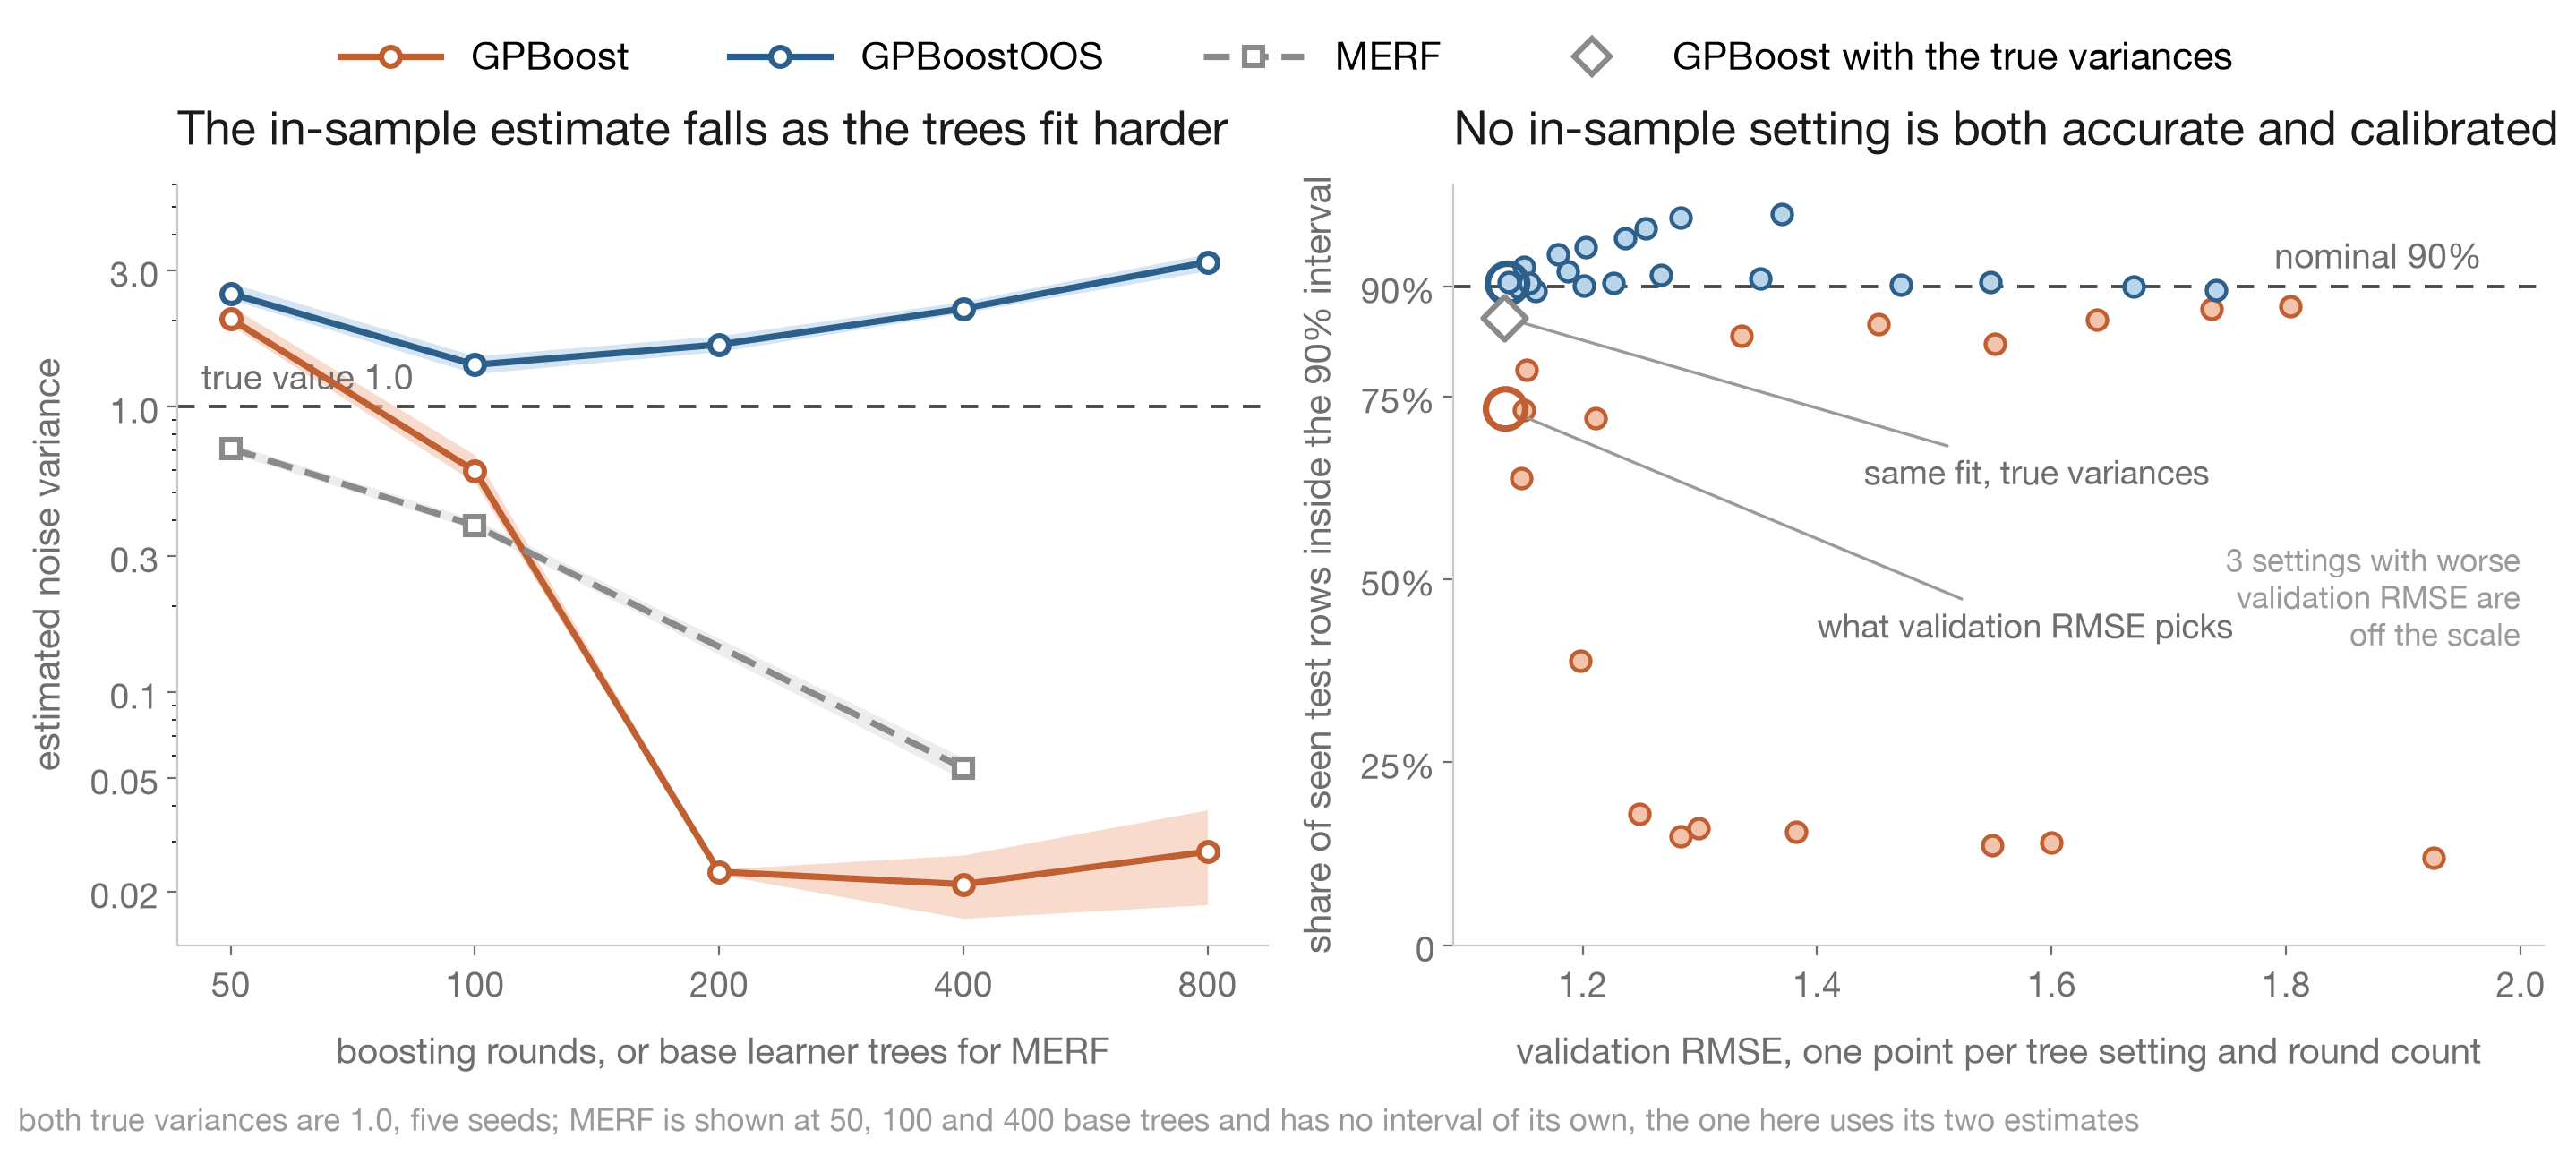

In [14]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import NullFormatter, NullLocator

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
BLUE_F, BLUE_E = "#B9D5EC", "#2C5F8A"
CORAL_F, CORAL_E = "#F4C3AC", "#C05F32"
GREY_F, GREY_E = "#E2E2E2", "#8a8a8a"
INK, MUTED, FAINT = "#1a1a1a", "#6e6e6e", "#9a9a9a"

fig, axes = plt.subplots(1, 2, figsize=(14.4, 6.4), dpi=200)
fig.patch.set_facecolor("white")

# left: the mechanism, at the shared default tree structure
base = grid[(grid.leaves == BASE["num_leaves"]) & (grid.min_data == BASE["min_data_in_leaf"])]
merf10 = res[res.model.str.contains("trees, 10 iters")]
ax = axes[0]
for frame, ec, fc, mk, ls in [(base[base.model == "GPBoost"], CORAL_E, CORAL_F, "o", "-"),
                              (base[base.model == "GPBoostOOS"], BLUE_E, BLUE_F, "o", "-"),
                              (merf10, GREY_E, GREY_F, "s", (0, (4, 2)))]:
    g = frame.groupby("M")["s2"]
    x = g.mean().index.values
    ax.fill_between(x, g.min().values, g.max().values, color=fc, alpha=0.6, lw=0, zorder=2)
    ax.plot(x, g.mean().values, color=ec, lw=2.6, ls=ls, marker=mk, ms=7.5, mfc="white",
            mew=2.2, zorder=4)
ax.axhline(1.0, color="#4a4a4a", lw=1.4, ls=(0, (5, 4)), zorder=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks([50, 100, 200, 400, 800]); ax.set_xticklabels(["50", "100", "200", "400", "800"])
ax.xaxis.set_minor_formatter(NullFormatter()); ax.xaxis.set_minor_locator(NullLocator())
ax.set_xlim(43, 950); ax.set_ylim(0.013, 6.0)
ax.set_yticks([0.02, 0.05, 0.1, 0.3, 1.0, 3.0])
ax.set_yticklabels(["0.02", "0.05", "0.1", "0.3", "1.0", "3.0"])
ax.text(46, 1.08, "true value 1.0", fontsize=14, color=MUTED, va="bottom")
ax.set_xlabel("boosting rounds, or base learner trees for MERF", fontsize=14.5, color=MUTED,
              labelpad=10)
ax.set_ylabel("estimated noise variance", fontsize=15, color=MUTED, labelpad=9)
ax.set_title("The in-sample estimate falls as the trees fit harder", fontsize=19, color=INK, pad=16, loc="left")

# right: the consequence, every configuration on the tuning grid
ax = axes[1]
for model, ec, fc in [("GPBoost", CORAL_E, CORAL_F), ("GPBoostOOS", BLUE_E, BLUE_F)]:
    g = grid[grid.model == model].groupby(["leaves", "min_data", "M"])[
        ["rmse_val", "cov_test"]].mean()
    ax.scatter(g.rmse_val, g.cov_test, s=62, facecolor=fc, edgecolor=ec, lw=1.6, zorder=3)
    p = res[res.model == model]
    ax.scatter([p.rmse_val.mean()], [p.cov_test.mean()], s=250, facecolor="none", edgecolor=ec,
               lw=2.6, zorder=5)
t = res[res.model == "GPBoost, true cov pars at scoring"]
ax.scatter([t.rmse_val.mean()], [t.cov_test.mean()], s=150, marker="D", facecolor="white",
           edgecolor=GREY_E, lw=2.2, zorder=5)
ax.axhline(0.90, color="#4a4a4a", lw=1.4, ls=(0, (5, 4)), zorder=1)
ax.set_ylim(0, 1.04); ax.set_xlim(1.09, 2.02)
ax.set_yticks([0, 0.25, 0.5, 0.75, 0.9])
ax.set_yticklabels(["0", "25%", "50%", "75%", "90%"])
ax.text(1.79, 0.915, "nominal 90%", fontsize=14, color=MUTED, va="bottom")
ax.text(2.0, 0.40, "3 settings with worse\nvalidation RMSE are\noff the scale", fontsize=12.5,
        color=FAINT, ha="right", va="bottom")
ax.annotate("what validation RMSE picks", xy=(res[res.model == "GPBoost"].rmse_val.mean(),
            res[res.model == "GPBoost"].cov_test.mean()), xytext=(1.40, 0.42),
            fontsize=13.5, color=MUTED,
            arrowprops=dict(arrowstyle="-", color=FAINT, lw=1.2, shrinkA=2, shrinkB=9))
ax.annotate("same fit, true variances", xy=(t.rmse_val.mean(), t.cov_test.mean()),
            xytext=(1.44, 0.63), fontsize=13.5, color=MUTED,
            arrowprops=dict(arrowstyle="-", color=FAINT, lw=1.2, shrinkA=2, shrinkB=7))
ax.set_xlabel("validation RMSE, one point per tree setting and round count", fontsize=14.5,
              color=MUTED, labelpad=10)
ax.set_ylabel("share of seen test rows inside the 90% interval", fontsize=15, color=MUTED,
              labelpad=9)
ax.set_title("No in-sample setting is both accurate and calibrated", fontsize=19, color=INK, pad=16, loc="left")

for ax in axes:
    ax.tick_params(labelsize=14, colors=MUTED, length=4)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c9c9c9")

handles = [Line2D([], [], color=CORAL_E, lw=2.6, marker="o", ms=7.5, mfc="white", mew=2.2),
           Line2D([], [], color=BLUE_E, lw=2.6, marker="o", ms=7.5, mfc="white", mew=2.2),
           Line2D([], [], color=GREY_E, lw=2.6, ls=(0, (4, 2)), marker="s", ms=7.5, mfc="white",
                  mew=2.2),
           Line2D([], [], color=GREY_E, lw=0, marker="D", ms=10, mfc="white", mew=2.2)]
fig.legend(handles, ["GPBoost", "GPBoostOOS", "MERF", "GPBoost with the true variances"],
           loc="upper center", ncol=4, frameon=False, fontsize=15.5, bbox_to_anchor=(0.5, 1.0),
           handlelength=2.6, columnspacing=2.6)
fig.text(0.008, 0.012, "both true variances are 1.0, five seeds; MERF is shown at 50, 100 and 400 "
         "base trees and has no interval of its own, the one here uses its two estimates",
         fontsize=12.5, color=FAINT, ha="left")
fig.tight_layout(rect=[0, 0.04, 1, 0.935])
fig.savefig("panel_merf_gpboost_variance.png", facecolor="white")
plt.show()

## What this run shows

- The group variance survives. The noise variance is measured on rows the fixed part already fitted,
  so it tracks how well the model fits its own training data rather than the noise.
- No configuration on the GPBoost grid is both accurate and calibrated. The best coverage its own
  interval reached was at the worst validation RMSE on the grid.
- Replacing the estimated covariance parameters with the true ones recovers most of the gap but not
  all of it. The rest is the error of the fitted ensemble, which the predictive variance has no term
  for. That is also why estimating the parameters out of sample overshoots the true noise variance
  and lands the interval on the safe side.
- For MERF the same mechanism is a version difference. merf 1.0 takes those residuals in sample;
  0.3 took them out of bag.
- Point accuracy separates these methods far less than the variance does. Over five seeds GPBoost
  averages a little ahead of LightGBM with the unit id as a categorical feature, but the paired
  table shows the gap running from GPBoost losing by 2.5% to winning by 5.5%, so on this panel it
  is not a reason to choose one over the other. LightGBM only gets into that range once
  `cat_smooth` is low enough for the id to be used at all.

One synthetic panel with independent rows inside each unit, five seeds. Run the same check on your
own data before trusting either variance estimate.